<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

<br>
<h1 style="font-family:verdana; font-size:26px"> <center>Notebook Tugas Besar 2 IF3170 Inteligensi Artifisial 2025/2026</center> </h1>
<br>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# **Group 4 - CriterionIsAllYouNeed**

<p style = "font-size:16px; font-family:verdana"> 13523004 - Razi Rachman Widyadhana<p>

<p style = "font-size:16px; font-family:verdana"> 13523052 - Adhimas Aryo Bimo<p>

<p style = "font-size:16px; font-family:verdana"> 13523105 - Muhammad Fathur Rizky <p>

<p style = "font-size:16px; font-family:verdana"> 13523114- Guntara Hambali <p>

<p style = "font-size:16px; font-family:verdana"> 13523121- Ahmad Wicaksono <p>

<br>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Daftar Isi

1. [**Introduction**](#1)

2. [**Exploratory Data Analysis**](#2)

3. [**Data Preprocessing**](#3)

4. [**Modeling & Validation**](#4)

5. [**Inference**](#5)

6. [**Bonus**](#6)

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Introduction <a name="1"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## Permasalahan

*Kesuksesan akademik mahasiswa dipengaruhi oleh banyak faktor, seperti demografi, status sosial-ekonomi, kebiasaan belajar, dan prestasi akademik sebelumnya. Mengidentifikasi mahasiswa yang berisiko dropout atau berpotensi berprestasi tinggi secara manual sangat sulit karena keragaman dan kompleksitas data.*

*Dataset yang tersedia berisi informasi demografis, sosial-ekonomi, dan riwayat akademik mahasiswa dari berbagai program sarjana.*

*Oleh karena itu, tugas ini bertujuan **membangun model machine learning** yang dapat **mengklasifikasikan status akademik mahasiswa** (misalnya lulus tepat waktu, dropout, atau kategori prestasi lainnya) serta mengidentifikasi faktor-faktor paling berpengaruh terhadap kesuksesan akademik mereka.*

---

## Data Gathering

*Data untuk eksperimen ini bersumber dari dataset yang disediakan melalui **Google Drive**, khususnya dari Spesifikasi Tugas Besar 2 AI dengan pranala: https://drive.google.com/drive/folders/1F9bm9juySngtfBT6y2LgigJlBegwCzIA*

*Dataset yang digunakan merupakan gambaran tentang mahasiswa yang terdaftar dalam berbagai program sarjana yang ditawarkan oleh perguruan tinggi.*

*Data ini mencakup data demografis, faktor sosial-ekonomi, dan informasi kinerja akademik yang dapat digunakan untuk menganalisis faktor-faktor yang mungkin memprediksi tingkat kesuksesan akademik mahasiswa.*

---

## Requirements & Config

In [1]:
# %pip install numpy pandas scipy matplotlib seaborn cvxopt scikit-learn

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import norm

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import sys
import os
import io

sys.path.append(os.getcwd())
from allyouneed.base import BaseEstimator, TransformerMixin
from allyouneed.tree import DecisionTreeClassifier
from allyouneed.linear_model import LogisticRegression
from allyouneed.svm import MulticlassSVC
from allyouneed.model_selection import StratifiedHoldout, StratifiedKFold
from allyouneed.metrics import Accuracy, F1Score
from allyouneed.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from allyouneed.feature_selection import ForwardFeatureSelection, BackwardFeatureElimination
# from allyouneed.decomposition import PCA

# Benchmark models from sklearn
from sklearn.tree import DecisionTreeClassifier as SklearnDecisionTreeClassifier
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.svm import SVC as SklearnSVC
# from sklearn.decomposition import PCA as SklearnPCA

import warnings
warnings.filterwarnings("ignore")

In [3]:
class settings:
    DATA_DIR = "../dataset/"
    TRAIN_FILE = "train.csv"
    TEST_FILE = "test.csv"
    SUBMISSION_FILE = "sample_submission.csv"
    INDEX_COL = "Student_ID"
    SEED = 42
    TARGET = "Target"
    TRAIN_PATH = DATA_DIR + TRAIN_FILE
    TEST_PATH = DATA_DIR + TEST_FILE
    SUBMISSION_PATH = DATA_DIR + SUBMISSION_FILE

In [4]:
np.random.seed(settings.SEED)
pd.set_option('display.max_columns', None)

rc_params = {
    "grid.color": "#EBEBE7",
    "font.family": "serif",
}

plt.rcParams.update(rc_params)

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Exploratory Data Analysis <a name="2"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## Muat Dataset

In [5]:
train = pd.read_csv(settings.TRAIN_PATH, index_col=settings.INDEX_COL)
test = pd.read_csv(settings.TEST_PATH, index_col=settings.INDEX_COL)
submission = pd.read_csv(settings.SUBMISSION_PATH, index_col=settings.INDEX_COL)

In [6]:
train

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
Student_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3743,1,17,1,9670,1,1,118.0,1,19,38,7,9,113.5,1,0,0,1,0,1,19,0,0,6,9,5,13.500000,0,0,6,6,6,14.000000,0,12.4,0.5,1.79,Graduate
3540,1,1,1,9070,1,1,139.0,1,1,19,3,9,134.9,1,0,0,1,1,0,20,0,0,6,7,6,13.666667,0,0,6,7,6,12.166667,1,16.2,0.3,-0.92,Graduate
1118,1,1,1,9500,1,1,138.0,1,38,19,9,5,144.3,0,0,0,1,0,0,20,0,0,7,9,6,12.700000,0,0,8,8,7,13.571429,0,13.9,-0.3,0.79,Graduate
791,1,17,1,9773,1,1,138.0,1,1,19,9,9,124.0,0,0,0,1,0,1,19,0,0,6,6,6,13.166667,0,0,6,6,6,13.833333,0,11.1,0.6,2.02,Graduate
4381,1,7,1,9500,1,2,140.0,1,38,37,7,8,140.0,0,0,0,1,0,0,29,0,0,8,14,4,11.325000,1,0,8,14,4,11.325000,1,12.7,3.7,-1.70,Dropout
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
898,1,43,1,9070,1,39,130.0,1,19,37,5,9,124.0,1,0,0,1,0,1,21,0,4,12,12,12,13.333333,0,5,12,12,11,12.545455,0,15.5,2.8,-4.06,Graduate
1998,1,17,1,9773,1,1,121.0,1,37,37,9,9,122.4,0,0,0,1,0,0,18,0,0,6,7,6,12.857143,0,0,6,6,6,13.333333,0,13.9,-0.3,0.79,Graduate
72,1,17,1,9500,1,1,150.0,1,37,19,8,4,130.8,0,0,0,1,1,0,24,0,0,7,8,7,11.975000,0,0,8,8,8,13.750000,0,13.9,-0.3,0.79,Graduate


---

## Normalisasi Nama Kolom

In [7]:
train.columns = train.columns.str.replace(r'\s+', '_', regex=True).str.replace('/', '_').str.replace("'", '').str.strip('_')
test.columns = test.columns.str.replace(r'\s+', '_', regex=True).str.replace('/', '_').str.replace("'", '').str.strip('_')

---

## Tipe Data tiap Fitur

In [8]:
buffer = io.StringIO()
train.info(buf=buffer)

lines = buffer.getvalue().splitlines()
types_info = (pd.DataFrame([x.split() for x in lines[5:-2]], columns=lines[3].split())).drop(['Count', 'Non-Null', '#'], axis=1)
types_info.set_index('Column')

,Dtype
Column,
Marital_status,int64
Application_mode,int64
Application_order,int64
Course,int64
Daytime_evening_attendance,int64
Previous_qualification,int64
Previous_qualification_(grade),float64
Nacionality,int64
Mothers_qualification,int64


---

## Unique Values

In [9]:
train.nunique().to_frame(name='nunique')

,nunique
Marital_status,6
Application_mode,18
Application_order,8
Course,17
Daytime_evening_attendance,2
Previous_qualification,17
Previous_qualification_(grade),96
Nacionality,17
Mothers_qualification,28
Fathers_qualification,32


---

## Data Duplikat

In [10]:
train[train.duplicated(keep=False)]

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_(grade),Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_(credited),Curricular_units_1st_sem_(enrolled),Curricular_units_1st_sem_(evaluations),Curricular_units_1st_sem_(approved),Curricular_units_1st_sem_(grade),Curricular_units_1st_sem_(without_evaluations),Curricular_units_2nd_sem_(credited),Curricular_units_2nd_sem_(enrolled),Curricular_units_2nd_sem_(evaluations),Curricular_units_2nd_sem_(approved),Curricular_units_2nd_sem_(grade),Curricular_units_2nd_sem_(without_evaluations),Unemployment_rate,Inflation_rate,GDP,Target
Student_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


In [11]:
train.duplicated().sum()

0

---

# Missing Values

In [12]:
missing_count = train.isnull().sum().rename('Missing Count')
missing_ratio = (train.isnull().mean()*100).rename('Missing Percentage (%)')
summary = missing_count.to_frame().join(missing_ratio.to_frame())
summary.sort_values(["Missing Percentage (%)"], ascending = [0])

,Missing Count,Missing Percentage (%)
Marital_status,0,0.0
Age_at_enrollment,0,0.0
Curricular_units_1st_sem_(credited),0,0.0
Curricular_units_1st_sem_(enrolled),0,0.0
Curricular_units_1st_sem_(evaluations),0,0.0
Curricular_units_1st_sem_(approved),0,0.0
Curricular_units_1st_sem_(grade),0,0.0
Curricular_units_1st_sem_(without_evaluations),0,0.0
Curricular_units_2nd_sem_(credited),0,0.0
Curricular_units_2nd_sem_(enrolled),0,0.0


In [13]:
train.isnull().sum().sum()

0

---

## Statistika Deskriptif

Dari insight sebelumnya, yaudah pisah jadi fitur numerical dan fitur categorical.

Biar enak preprocessing sama EDA yang sesuai untuk setiap jenis fitur sehingga model dapat mempelajari data dengan lebih efektif dan menghasilkan prediksi yang lebih akurat.

In [14]:
col = list(train.columns)
col.remove("Target")

num_features = ["Previous_qualification_(grade)",
                "Admission_grade",
                "Age_at_enrollment",
                "Curricular_units_1st_sem_(credited)",
                "Curricular_units_1st_sem_(enrolled)",
                "Curricular_units_1st_sem_(evaluations)",
                "Curricular_units_1st_sem_(approved)",
                "Curricular_units_1st_sem_(grade)",
                "Curricular_units_1st_sem_(without_evaluations)",
                "Curricular_units_2nd_sem_(credited)",
                "Curricular_units_2nd_sem_(enrolled)",
                "Curricular_units_2nd_sem_(evaluations)",
                "Curricular_units_2nd_sem_(approved)",
                "Curricular_units_2nd_sem_(grade)",
                "Curricular_units_2nd_sem_(without_evaluations)",
                "Unemployment_rate",
                "Inflation_rate",
                "GDP"]

ord_features = ["Application_order", 
                "Previous_qualification"]

bin_features = [feat for feat in col if train[feat].nunique() == 2 and feat not in ord_features]

cat_features = ["Marital_status",
                "Application_mode",
                "Course",
                "Nacionality",
                "Mothers_qualification",
                "Fathers_qualification",
                "Mothers_occupation",
                "Fathers_occupation"]

print("Numerical Features:", len(num_features)
      , "\nOrdinal Features:", len(ord_features)
      , "\nBinary Features:", len(bin_features)
      , "\nCategorical Features:", len(cat_features)
      , "\nTotal Features (without id and target):", len(num_features) + len(ord_features) + len(bin_features) + len(cat_features))

Numerical Features: 18 
Ordinal Features: 2 
Binary Features: 8 
Categorical Features: 8 
Total Features (without id and target): 36


### Distribusi `Target`

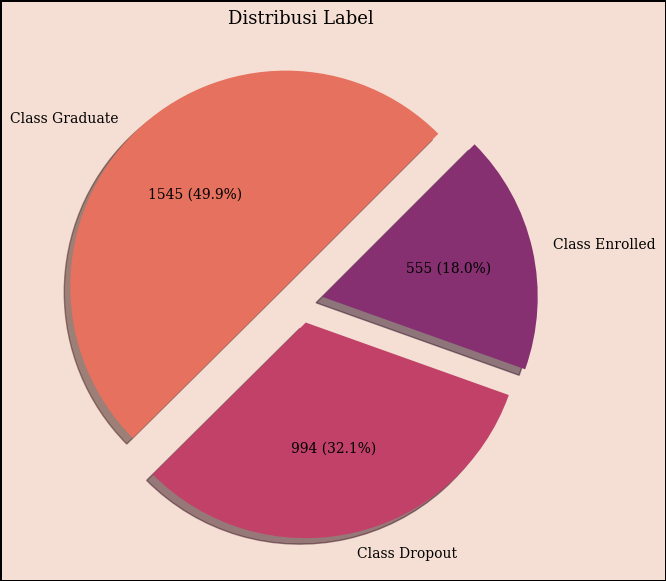

In [15]:
fig, ax = plt.subplots(figsize=(7, 7), facecolor='#f5ded3')
fig.patch.set_linewidth(2)  
fig.patch.set_edgecolor('black')

value_counts = train['Target'].value_counts()
counts = value_counts.values
labels = value_counts.index

colors = sns.color_palette('flare', n_colors=len(labels))

def autopct_format(pct):
    absolute = int(pct/100.*counts.sum())
    return f'{absolute} ({pct:.1f}%)'

ax = plt.pie(counts,
             labels=[f'Class {label}' for label in labels],
             autopct=autopct_format,
             explode=[0.1] * len(labels),
             colors=colors,
             shadow=True,
             startangle=45
)

plt.title('Distribusi Label', fontsize=13)
plt.show()

### `num_features`

In [16]:
train[num_features + ord_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Previous_qualification_(grade),3096.0,132.762435,13.137942,95.00,125.00,133.100000,140.000000,190.000000
Admission_grade,3096.0,126.915698,14.459928,95.00,117.80,126.000000,135.000000,190.000000
Age_at_enrollment,3096.0,23.216408,7.614394,17.00,19.00,20.000000,25.000000,70.000000
Curricular_units_1st_sem_(credited),3096.0,0.713501,2.365945,0.00,0.00,0.000000,0.000000,20.000000
Curricular_units_1st_sem_(enrolled),3096.0,6.245801,2.501305,0.00,5.00,6.000000,7.000000,26.000000
Curricular_units_1st_sem_(evaluations),3096.0,8.242571,4.186787,0.00,6.00,8.000000,10.000000,45.000000
Curricular_units_1st_sem_(approved),3096.0,4.697674,3.087995,0.00,3.00,5.000000,6.000000,26.000000
Curricular_units_1st_sem_(grade),3096.0,10.621631,4.880632,0.00,11.00,12.333333,13.400000,18.875000
Curricular_units_1st_sem_(without_evaluations),3096.0,0.140181,0.672843,0.00,0.00,0.000000,0.000000,12.000000
Curricular_units_2nd_sem_(credited),3096.0,0.539729,1.906634,0.00,0.00,0.000000,0.000000,19.000000


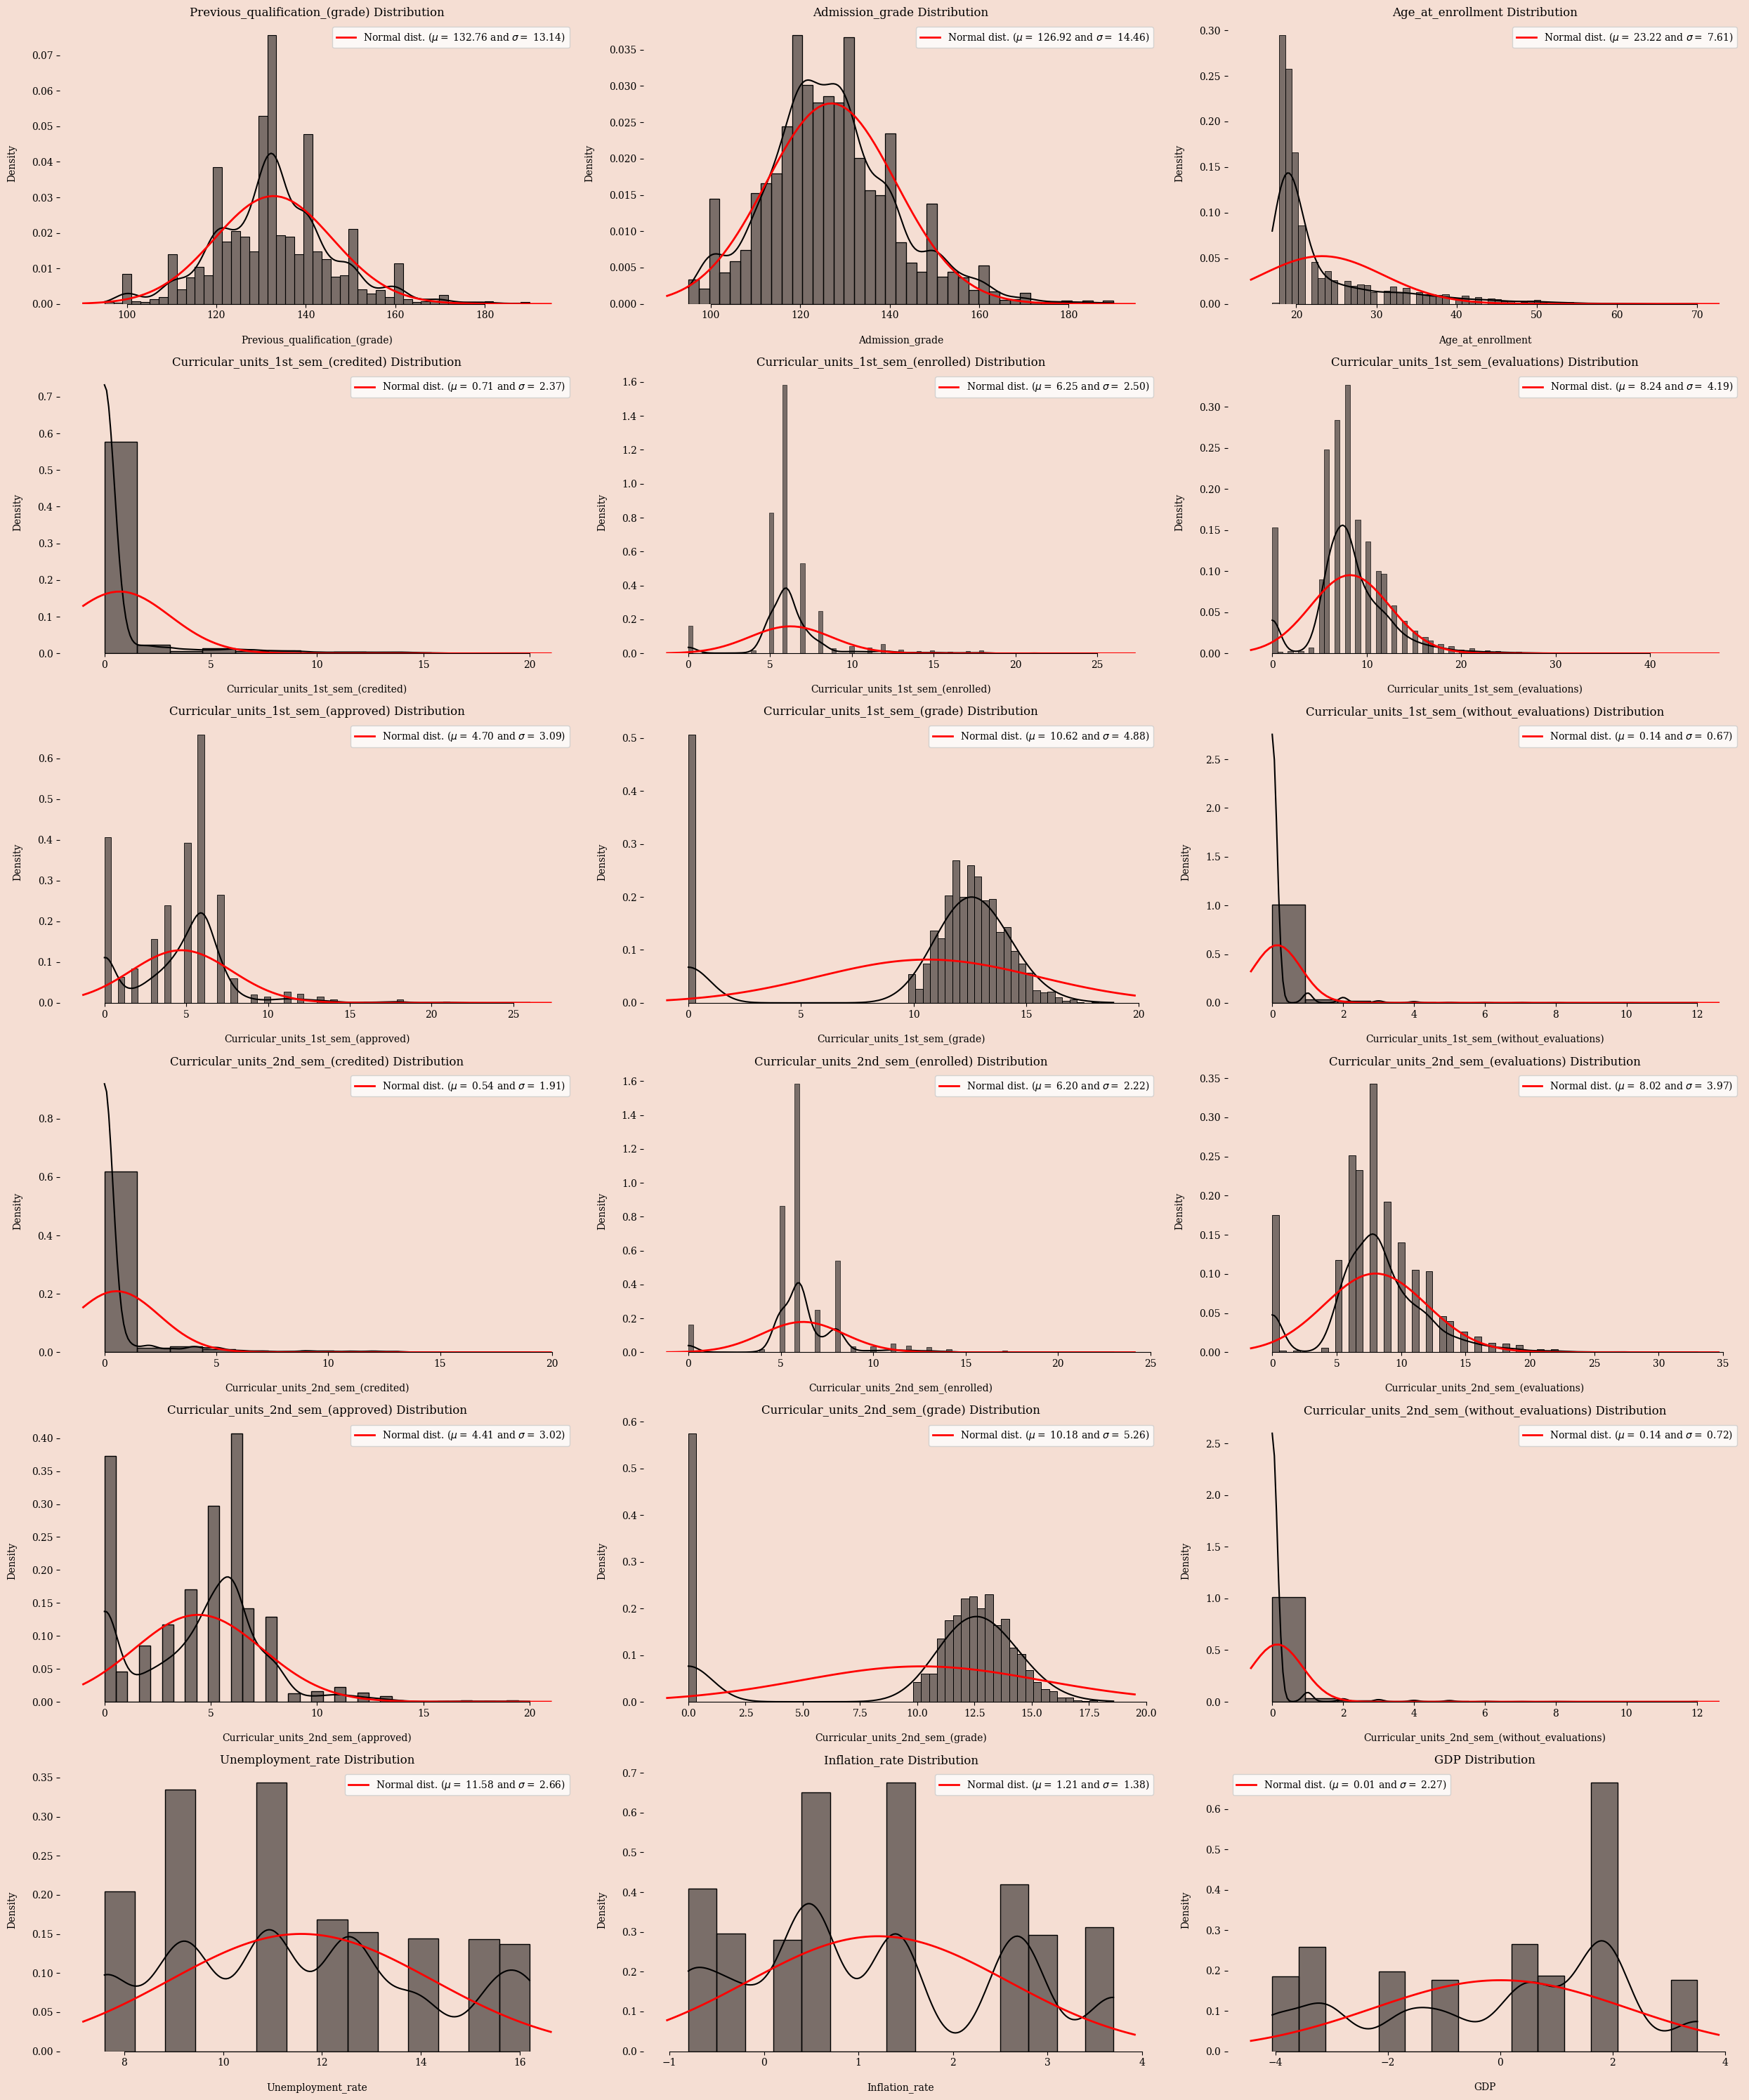

In [17]:
n_features = len(num_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(25, 5 * n_rows), facecolor='#f5ded3')

for index, feature in enumerate(num_features):
    
    ax = plt.subplot(n_rows, n_cols, index + 1)
    sns.histplot(data=train, x=feature, kde=True, stat='density', color='#000000', ax=ax)
    
    feature_data = train[feature].dropna()
    (mu, sigma) = norm.fit(feature_data)
    
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, sigma)
    
    ax.plot(x, p, 'r-', linewidth=2, label=f'Normal dist. ($\\mu=$ {mu:.2f} and $\\sigma=$ {sigma:.2f})')
    
    ax.legend(loc='best')
    ax.xaxis.grid(False)
    ax.set_facecolor('#f5ded3')
    ax.set_ylabel("Density", labelpad=15)
    ax.set_xlabel(feature, labelpad=15)  
    ax.set_title(f"{feature} Distribution")
    sns.despine(trim=True, left=True)

plt.tight_layout()
plt.show()

---

## Outliers?

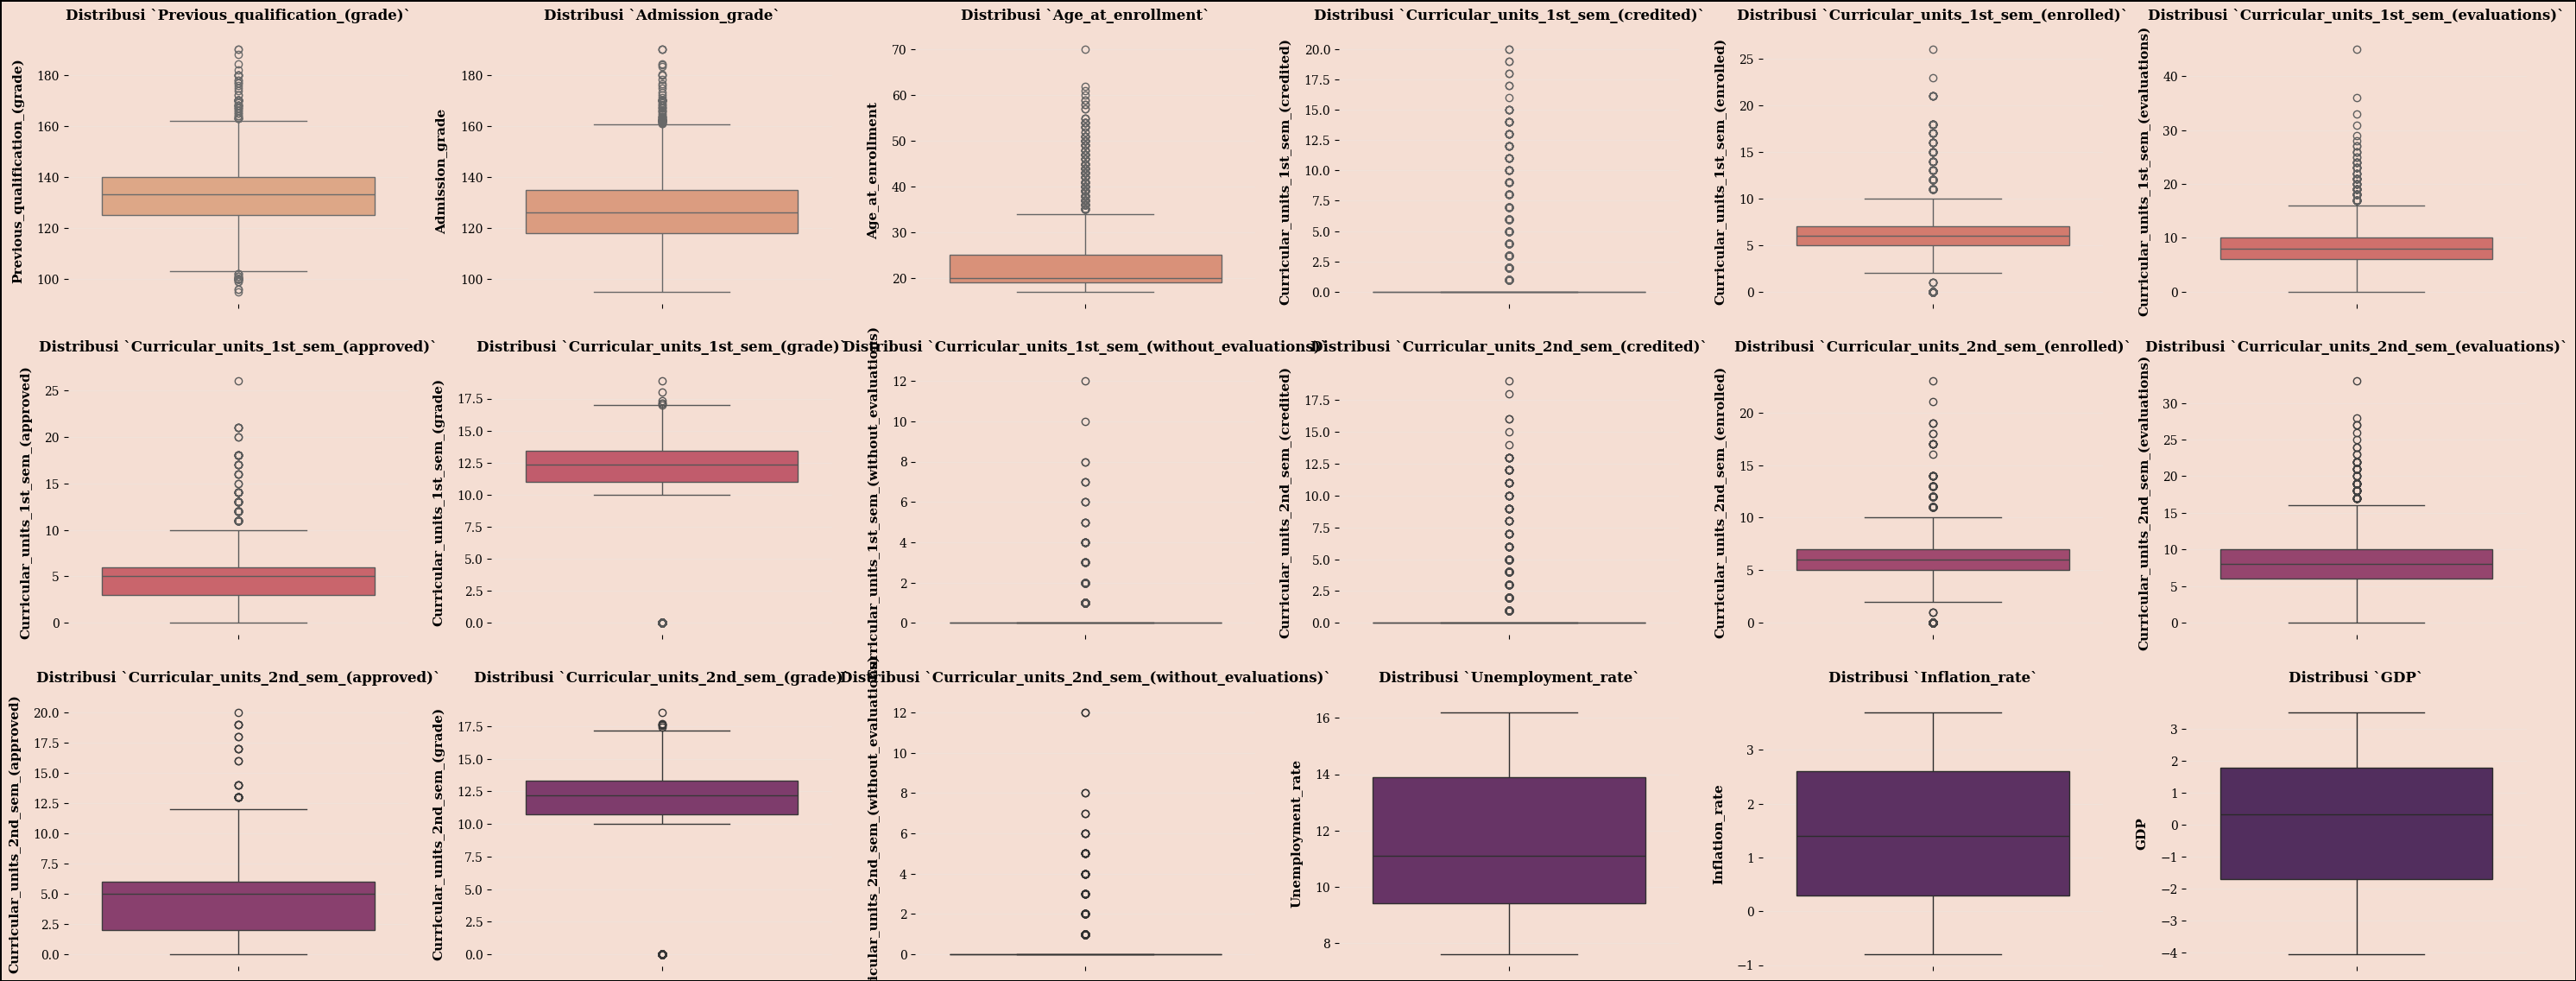

In [18]:
n_features = len(num_features)
n_cols = 6
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(30, n_rows * 4), facecolor='#f5ded3')
fig.patch.set_linewidth(2)
fig.patch.set_edgecolor('black')

if n_rows == 1:
    axes = axes if n_features > 1 else [axes]
else:
    axes = axes.flatten()

colors = sns.color_palette('flare', n_features)

for i, feature in enumerate(num_features):
    ax = axes[i]
    
    sns.boxplot(data=train, y=feature, palette=[colors[i]], ax=ax)
    
    ax.set_facecolor('#f5ded3')
    ax.set_title(f'Distribusi `{feature}`', fontsize=12, fontweight='bold', pad=15)
    ax.set_ylabel(feature, fontsize=11, fontweight='bold', labelpad=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=10)
    
    ax.set_xlabel('')
    
    ax.grid(True, alpha=0.3, axis='y')
    
    sns.despine(ax=ax, trim=True, left=True)

for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(pad=3.0, h_pad=3.0, w_pad=2.0)
plt.show()

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Preprocessing <a name="3"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## Data Transformation & Dimensionality Reduction

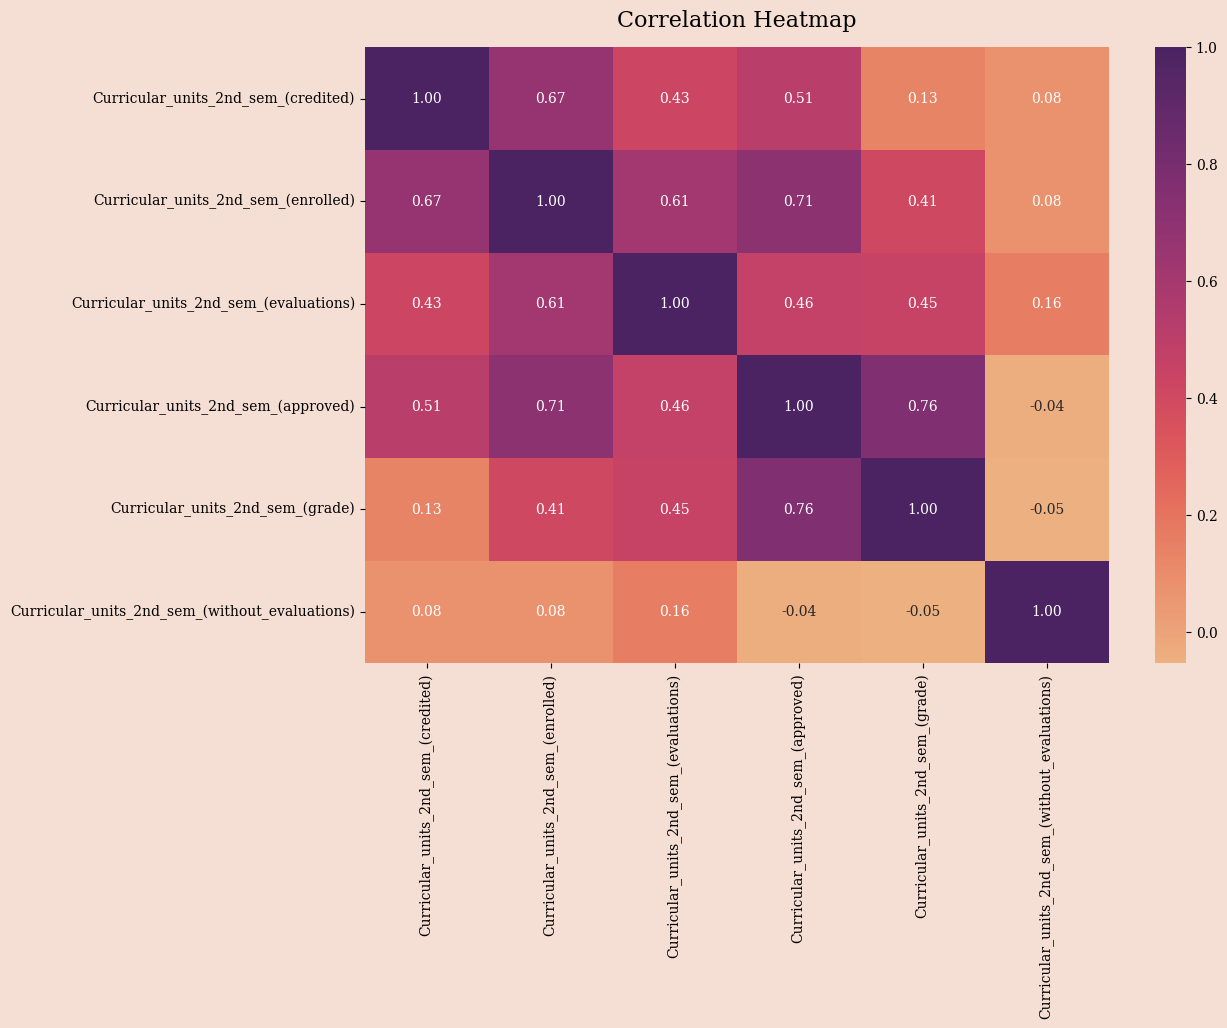

In [19]:
plt.figure(figsize=(12, 8), facecolor='#f5ded3')

sns.heatmap(train[['Curricular_units_2nd_sem_(credited)',
                'Curricular_units_2nd_sem_(enrolled)',
                'Curricular_units_2nd_sem_(evaluations)',
                'Curricular_units_2nd_sem_(approved)',
                'Curricular_units_2nd_sem_(grade)',
                'Curricular_units_2nd_sem_(without_evaluations)',]].select_dtypes(include=[np.number]).corr(), annot=True, fmt=".2f", cmap='flare')

plt.title('Correlation Heatmap', fontsize=16, pad=15)
plt.show()

In [20]:
label_encoder = LabelEncoder()
label_encoder.fit(train[settings.TARGET])

class Preprocessing(BaseEstimator, TransformerMixin):
    def __init__(self, initial_cols=None, numeric_cols=None, binary_cols=None, categorical_cols=None, dropped_cols=None, z_threshold=1.9):
        self.categorical_cols = categorical_cols or []
        self.binary_cols = binary_cols or []
        self.numeric_cols = numeric_cols or []
        self.dropped_cols = dropped_cols or []
        self.initial_cols = initial_cols or []
        
        self.ohe = OneHotEncoder(columns=self.categorical_cols, dtype=float)
        self.scaler = StandardScaler()
        self.fitted = False
        
        self.z_threshold = z_threshold
        self.zscore_params = {}

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise ValueError("X must be a pandas DataFrame")

        if self.initial_cols:
            X = X[self.initial_cols]

        if self.dropped_cols:
            X = X.drop(columns=self.dropped_cols)

        # mean & std untuk Z-score clipping
        self.zscore_params = {}
        for col in self.numeric_cols:
            mean = X[col].mean()
            std = X[col].std()
            self.zscore_params[col] = (mean, std)

        self.ohe.fit(X)
        self.scaler.fit(X[self.numeric_cols])

        self.fitted = True
        return self

    def transform(self, X):
        if not self.fitted:
            raise ValueError("Preprocessing must be fitted before transform()")

        if self.initial_cols:
            X = X[self.initial_cols]

        if self.dropped_cols:
            X = X.drop(columns=self.dropped_cols)

        X_num = X[self.numeric_cols].astype(float)

        # Z-score clipping
        for col in self.numeric_cols:
            mean, std = self.zscore_params[col]
            z = (X_num[col] - mean) / std
            z = z.clip(-self.z_threshold, self.z_threshold)
            X_num[col] = z * std + mean

        # categorical
        X_cat_array = self.ohe.transform(X)
        X_cat = pd.DataFrame(
            X_cat_array,
            columns=self.ohe.feature_names_,
            index=X.index
        )

        # binary features (no encoding needed)
        X_bin = X[self.binary_cols].astype(float)

        # scaling
        X_num_scaled = self.scaler.transform(X_num)
        X_num = pd.DataFrame(X_num_scaled, columns=self.numeric_cols, index=X.index)

        return pd.concat([X_num, X_bin, X_cat], axis=1)

initial_features = []
dropped_features = ["Mothers_qualification", "Fathers_qualification"]
cat_features = [col for col in cat_features if col not in dropped_features]

preprocessor = Preprocessing(
    initial_cols=initial_features,
    numeric_cols=num_features + ord_features,
    binary_cols=bin_features,
    categorical_cols=cat_features,
    dropped_cols=dropped_features,
    z_threshold=2.0
)

target = train[settings.TARGET]
train  = train.drop(columns=[settings.TARGET])
train  = preprocessor.fit_transform(train).copy(deep = True)

In [21]:
train

,Previous_qualification_(grade),Admission_grade,Age_at_enrollment,Curricular_units_1st_sem_(credited),Curricular_units_1st_sem_(enrolled),Curricular_units_1st_sem_(evaluations),Curricular_units_1st_sem_(approved),Curricular_units_1st_sem_(grade),Curricular_units_1st_sem_(without_evaluations),Curricular_units_2nd_sem_(credited),Curricular_units_2nd_sem_(enrolled),Curricular_units_2nd_sem_(evaluations),Curricular_units_2nd_sem_(approved),Curricular_units_2nd_sem_(grade),Curricular_units_2nd_sem_(without_evaluations),Unemployment_rate,Inflation_rate,GDP,Application_order,Previous_qualification,Daytime_evening_attendance,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,International,Marital_status__1,Marital_status__2,Marital_status__3,Marital_status__4,Marital_status__5,Marital_status__6,Application_mode__1,Application_mode__10,Application_mode__15,Application_mode__16,Application_mode__17,Application_mode__18,Application_mode__2,Application_mode__26,Application_mode__27,Application_mode__39,Application_mode__42,Application_mode__43,Application_mode__44,Application_mode__5,Application_mode__51,Application_mode__53,Application_mode__57,Application_mode__7,Course__171,Course__33,Course__8014,Course__9003,Course__9070,Course__9085,Course__9119,Course__9130,Course__9147,Course__9238,Course__9254,Course__9500,Course__9556,Course__9670,Course__9773,Course__9853,Course__9991,Nacionality__1,Nacionality__100,Nacionality__101,Nacionality__103,Nacionality__105,Nacionality__108,Nacionality__11,Nacionality__13,Nacionality__14,Nacionality__2,Nacionality__21,Nacionality__22,Nacionality__24,Nacionality__26,Nacionality__41,Nacionality__6,Nacionality__62,Mothers_occupation__0,Mothers_occupation__1,Mothers_occupation__10,Mothers_occupation__122,Mothers_occupation__123,Mothers_occupation__131,Mothers_occupation__132,Mothers_occupation__134,Mothers_occupation__141,Mothers_occupation__143,Mothers_occupation__144,Mothers_occupation__151,Mothers_occupation__152,Mothers_occupation__153,Mothers_occupation__171,Mothers_occupation__173,Mothers_occupation__175,Mothers_occupation__191,Mothers_occupation__192,Mothers_occupation__193,Mothers_occupation__194,Mothers_occupation__2,Mothers_occupation__3,Mothers_occupation__4,Mothers_occupation__5,Mothers_occupation__6,Mothers_occupation__7,Mothers_occupation__8,Mothers_occupation__9,Mothers_occupation__90,Mothers_occupation__99,Fathers_occupation__0,Fathers_occupation__1,Fathers_occupation__10,Fathers_occupation__101,Fathers_occupation__102,Fathers_occupation__103,Fathers_occupation__112,Fathers_occupation__122,Fathers_occupation__123,Fathers_occupation__131,Fathers_occupation__135,Fathers_occupation__141,Fathers_occupation__143,Fathers_occupation__144,Fathers_occupation__151,Fathers_occupation__152,Fathers_occupation__153,Fathers_occupation__154,Fathers_occupation__161,Fathers_occupation__163,Fathers_occupation__171,Fathers_occupation__172,Fathers_occupation__175,Fathers_occupation__181,Fathers_occupation__182,Fathers_occupation__183,Fathers_occupation__192,Fathers_occupation__193,Fathers_occupation__194,Fathers_occupation__195,Fathers_occupation__2,Fathers_occupation__3,Fathers_occupation__4,Fathers_occupation__5,Fathers_occupation__6,Fathers_occupation__7,Fathers_occupation__8,Fathers_occupation__9,Fathers_occupation__90,Fathers_occupation__99
Student_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3743,-1.123830,-0.927934,-0.553831,-0.301620,-0.098285,0.180939,0.097919,0.589849,-0.208375,-0.283125,-0.090515,-0.508120,0.525811,0.726311,-0.19651,0.308075,-0.513880,0.786411,-0.55543,-0.353639,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

---

## Feature Selection

In [22]:
fs = ForwardFeatureSelection(
    estimator=SklearnDecisionTreeClassifier(criterion='gini', random_state=settings.SEED),
    n_features_to_select=50,
    scoring=F1Score(average='macro'),
    verbose=True,
    feature_names=train.columns.tolist(),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=settings.SEED),
)

In [23]:
# fs = BackwardFeatureElimination(
#     estimator=SklearnDecisionTreeClassifier(criterion='entropy', random_state=settings.SEED),
#     n_features_to_select=50,
#     scoring=F1Score(average='macro'),
#     verbose=True,
#     feature_names=train.columns.tolist(),
#     cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=settings.SEED),
# )

In [24]:
# fs.fit(X_train, y_train)
# fs.selected_features_

In [25]:
dtl_feats = ["Curricular_units_2nd_sem_(approved)", "Tuition_fees_up_to_date", "Course__9853", 
             "Fathers_occupation__0", "Course__9119", "Mothers_occupation__0", "Application_mode__15", 
             "Course__9556", "Fathers_occupation__90", "Mothers_occupation__7", "Nacionality__108", "Course__33", 
             "Marital_status__3", "Nacionality__6", "Application_mode__2", "Marital_status__6", "Nacionality__21", 
             "Mothers_occupation__132", "Fathers_occupation__161", "Mothers_occupation__123", "Course__9773", 
             "Curricular_units_2nd_sem_(enrolled)", "Course__9500", "Nacionality__101", "Course__9147", 
             "Fathers_occupation__2", "Course__171", "Mothers_occupation__192", "Course__9991", "Nacionality__11", 
             "Application_mode__42", "Mothers_occupation__99", "Mothers_occupation__141", "Mothers_occupation__193", 
             "Fathers_occupation__102", "Fathers_occupation__163", "Fathers_occupation__195", "Fathers_occupation__122", 
             "Fathers_occupation__175", "Fathers_occupation__141", "Mothers_occupation__175", "Fathers_occupation__154", 
             "Mothers_occupation__171", "Application_mode__57", "Mothers_occupation__153", "Fathers_occupation__143", 
             "Fathers_occupation__144", "Fathers_occupation__103", "Fathers_occupation__181"]

len(dtl_feats)

49

In [26]:
log_feats = ['Curricular_units_2nd_sem_(approved)', 'Curricular_units_2nd_sem_(evaluations)', 'Curricular_units_2nd_sem_(enrolled)', 
             'Tuition_fees_up_to_date', 'Curricular_units_2nd_sem_(grade)', 'Application_mode__44', 'Course__9991', 'Scholarship_holder', 
             'Fathers_occupation__0', 'Admission_grade', 'Course__9147', 'Age_at_enrollment', 'Fathers_occupation__3', 'Course__9238', 'Application_mode__57', 
             'Mothers_occupation__134', 'Course__9853', 'Application_mode__17', 'Fathers_occupation__182', 'Curricular_units_2nd_sem_(credited)', 'Fathers_occupation__154', 'Course__9119', 
             'Mothers_occupation__131', 'Fathers_occupation__131', 'Fathers_occupation__99', 'Unemployment_rate', 'Course__9130', 'Fathers_occupation__90', 'Mothers_occupation__6', 'Fathers_occupation__152', 
             'Mothers_occupation__192', 'Mothers_occupation__0', 'Daytime_evening_attendance', 'Course__8014', 'Fathers_occupation__103', 'GDP', 'Nacionality__2', 'Mothers_occupation__3', 'Mothers_occupation__152', 
             'Application_mode__7', 'Course__9670', 'Mothers_occupation__141', 'Mothers_occupation__193', 'Fathers_occupation__151', 'Marital_status__2', 'Application_mode__39', 
             'Fathers_occupation__2', 'Application_mode__53', 'Application_mode__10', 'Course__9556']

len(log_feats)

50

In [27]:
svm_feats = ['Curricular_units_2nd_sem_(approved)', 'Tuition_fees_up_to_date', 'Curricular_units_1st_sem_(enrolled)', 'Course__9853', 
             'Mothers_occupation__0', 'Scholarship_holder', 'Curricular_units_1st_sem_(approved)', 'Fathers_occupation__10', 'Mothers_occupation__90', 
             'Application_mode__53', 'Mothers_occupation__192', 'Course__9238', 'Course__9500', 'Mothers_occupation__6']

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Modeling & Validation <a name="4"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## Metrics

In [28]:
class ConfusionMatrix:
    def __call__(self, y_true, y_pred):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)

        labels = np.unique(np.concatenate([y_true, y_pred]))
        label_to_idx = {label: idx for idx, label in enumerate(labels)}
        
        cm = np.zeros((len(labels), len(labels)), dtype=int)

        for t, p in zip(y_true, y_pred):
            cm[label_to_idx[t], label_to_idx[p]] += 1
        
        return cm, labels

class MetricCollection:
    def __init__(self, metrics: dict):
        self.metrics = metrics

    def __call__(self, y_true, y_pred):
        return {name: metric(y_true, y_pred) for name, metric in self.metrics.items()}

In [29]:
holdout = StratifiedHoldout(test_size=0.2, shuffle=True, random_state=42)

In [30]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=settings.SEED)

metrics = MetricCollection({
    'accuracy': Accuracy(),
    'f1_macro': F1Score(average='macro'),
    'f1_micro': F1Score(average='micro'),
    'f1_weighted': F1Score(average='weighted')  
})

all_results = {} 

In [31]:
def cross_validate_model(name, model, X, y, metrics):

    print(f"Training model: {name}")
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    
        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx].values

        X_val = X.iloc[val_idx]
        y_val = y.iloc[val_idx].values

        model.fit(X_train, y_train)
        val_preds = model.predict(X_val)

        results = metrics(y_val, val_preds)
        fold_results.append(results)

        print(f"Fold {fold + 1} results: {results}")

    df_results = pd.DataFrame(fold_results)
    model_mean = df_results.mean().to_dict()

    print(f"\nAggregated results for model {name}:")
    print(df_results)
    print("Mean metrics:", model_mean)
    print("=" * 60)


---

## Decision Tree

In [32]:
X = train[dtl_feats].copy(deep=True)
y = target

In [33]:
X_train, X_test, y_train, y_test = holdout.train_test_split(X, y)

### Manual

In [ ]:
name = "Decision Tree Manual"
dtl  = DecisionTreeClassifier(criterion='gini', min_samples_split=8, max_depth=12, random_state=settings.SEED)

#### *Hold-out validation*

In [35]:
dtl.fit(X_train, y_train)
test_preds = dtl.predict(X_test)
test_results = metrics(y_test, test_preds)
test_results

{'accuracy': 0.7524271844660194,
 'f1_macro': 0.6810647241465032,
 'f1_micro': 0.7524271844660194,
 'f1_weighted': 0.7407265284892877}

In [36]:
ConfusionMatrix()(y_test, test_preds)

(array([[143,  17,  38],
        [ 21,  42,  48],
        [ 11,  18, 280]]),
 array(['Dropout', 'Enrolled', 'Graduate'], dtype=object))

#### *K-fold Validation*

In [37]:
cross_validate_model(name, dtl, X, y, metrics)

Training model: Decision Tree Manual
Fold 1 results: {'accuracy': 0.7632850241545893, 'f1_macro': 0.7014292290130218, 'f1_micro': 0.7632850241545892, 'f1_weighted': 0.7587968475924387}
Fold 2 results: {'accuracy': 0.7189014539579968, 'f1_macro': 0.6468147291488243, 'f1_micro': 0.7189014539579967, 'f1_weighted': 0.7150553112270419}
Fold 3 results: {'accuracy': 0.7705977382875606, 'f1_macro': 0.706280074926389, 'f1_micro': 0.7705977382875606, 'f1_weighted': 0.7646974577399255}
Fold 4 results: {'accuracy': 0.777059773828756, 'f1_macro': 0.729707412426427, 'f1_micro': 0.777059773828756, 'f1_weighted': 0.777341979893314}
Fold 5 results: {'accuracy': 0.7491909385113269, 'f1_macro': 0.6516370000426859, 'f1_micro': 0.7491909385113269, 'f1_weighted': 0.7279664862674011}

Aggregated results for model Decision Tree Manual:
   accuracy  f1_macro  f1_micro  f1_weighted
0  0.763285  0.701429  0.763285     0.758797
1  0.718901  0.646815  0.718901     0.715055
2  0.770598  0.706280  0.770598     0.764

### Scikit-learn

In [38]:
name = "Decision Tree Sklearn"
sklearn_dtl  = SklearnDecisionTreeClassifier(criterion='gini', min_samples_split=8, max_depth=12, random_state=settings.SEED)

#### *Hold-out validation*

In [ ]:
sklearn_dtl.fit(X_train, y_train)
test_preds = sklearn_dtl.predict(X_test)
test_results = metrics(y_test, test_preds)  
test_results

{'accuracy': 0.7556634304207119,
 'f1_macro': 0.6883526166749353,
 'f1_micro': 0.7556634304207119,
 'f1_weighted': 0.7466400055516901}

In [40]:
ConfusionMatrix()(y_test, test_preds)

(array([[146,  19,  33],
        [ 23,  45,  43],
        [ 13,  20, 276]]),
 array(['Dropout', 'Enrolled', 'Graduate'], dtype=object))

#### *K-fold Validation*

In [41]:
cross_validate_model(name, sklearn_dtl, X, y, metrics)

Training model: Decision Tree Sklearn
Fold 1 results: {'accuracy': 0.7632850241545893, 'f1_macro': 0.7010548845742242, 'f1_micro': 0.7632850241545892, 'f1_weighted': 0.7588066945989881}
Fold 2 results: {'accuracy': 0.7189014539579968, 'f1_macro': 0.6469713618911564, 'f1_micro': 0.7189014539579967, 'f1_weighted': 0.715596405926738}
Fold 3 results: {'accuracy': 0.7738287560581584, 'f1_macro': 0.7104128293936234, 'f1_micro': 0.7738287560581584, 'f1_weighted': 0.7680205496457544}
Fold 4 results: {'accuracy': 0.777059773828756, 'f1_macro': 0.729707412426427, 'f1_micro': 0.777059773828756, 'f1_weighted': 0.777341979893314}
Fold 5 results: {'accuracy': 0.7475728155339806, 'f1_macro': 0.6501295533538439, 'f1_micro': 0.7475728155339806, 'f1_weighted': 0.7270049343236407}

Aggregated results for model Decision Tree Sklearn:
   accuracy  f1_macro  f1_micro  f1_weighted
0  0.763285  0.701055  0.763285     0.758807
1  0.718901  0.646971  0.718901     0.715596
2  0.773829  0.710413  0.773829     0.7

---

## Logistic Regression

In [42]:
X = train[log_feats].copy(deep=True)
y = target

In [43]:
X_train, X_test, y_train, y_test = holdout.train_test_split(X, y)

### Manual

In [44]:
name = "Logistic Regression"
log  = LogisticRegression(solver='newton-cg', random_state=settings.SEED)

#### *Hold-out validation*

In [45]:
log.fit(X_train, y_train)
test_preds = log.predict(X_test)
test_results = metrics(y_test, test_preds)
test_results

{'accuracy': 0.7815533980582524,
 'f1_macro': 0.6963129905623545,
 'f1_micro': 0.7815533980582524,
 'f1_weighted': 0.7627396294453287}

In [46]:
ConfusionMatrix()(y_test, test_preds)

(array([[158,   9,  31],
        [ 29,  36,  46],
        [  8,  12, 289]]),
 array(['Dropout', 'Enrolled', 'Graduate'], dtype=object))

#### *K-fold Validation*

In [47]:
cross_validate_model(name, log, X, y, metrics)

Training model: Logistic Regression
Fold 1 results: {'accuracy': 0.789049919484702, 'f1_macro': 0.7000333213879301, 'f1_micro': 0.7890499194847019, 'f1_weighted': 0.769329258471707}
Fold 2 results: {'accuracy': 0.7560581583198708, 'f1_macro': 0.6648172353544677, 'f1_micro': 0.7560581583198708, 'f1_weighted': 0.7369573123551336}
Fold 3 results: {'accuracy': 0.7948303715670436, 'f1_macro': 0.7083749451711387, 'f1_micro': 0.7948303715670436, 'f1_weighted': 0.7758853661215943}
Fold 4 results: {'accuracy': 0.7867528271405493, 'f1_macro': 0.7090374108975062, 'f1_micro': 0.7867528271405492, 'f1_weighted': 0.7719514954381734}
Fold 5 results: {'accuracy': 0.7491909385113269, 'f1_macro': 0.6594472469744153, 'f1_micro': 0.7491909385113269, 'f1_weighted': 0.7274172243007525}

Aggregated results for model Logistic Regression:
   accuracy  f1_macro  f1_micro  f1_weighted
0  0.789050  0.700033  0.789050     0.769329
1  0.756058  0.664817  0.756058     0.736957
2  0.794830  0.708375  0.794830     0.77

### Scikit-learn

In [48]:
name = "Logistic Regression Sklearn"
sklearn_log = SklearnLogisticRegression(solver="newton-cg", random_state=settings.SEED)

#### *Hold-out validation*

In [49]:
sklearn_log.fit(X_train, y_train)
test_preds = sklearn_log.predict(X_test)
test_results = metrics(y_test, test_preds)
test_results

{'accuracy': 0.7783171521035599,
 'f1_macro': 0.7055762196652801,
 'f1_micro': 0.77831715210356,
 'f1_weighted': 0.7649748008859937}

In [50]:
ConfusionMatrix()(y_test, test_preds)

(array([[155,  11,  32],
        [ 25,  42,  44],
        [  9,  16, 284]]),
 array(['Dropout', 'Enrolled', 'Graduate'], dtype=object))

#### *K-fold validation*

In [51]:
cross_validate_model(name, sklearn_log, X, y, metrics)

Training model: Logistic Regression Sklearn
Fold 1 results: {'accuracy': 0.7809983896940419, 'f1_macro': 0.6958598908986505, 'f1_micro': 0.7809983896940419, 'f1_weighted': 0.7649266762924404}
Fold 2 results: {'accuracy': 0.7544426494345718, 'f1_macro': 0.6760286934207779, 'f1_micro': 0.754442649434572, 'f1_weighted': 0.7419936357618861}
Fold 3 results: {'accuracy': 0.7980613893376414, 'f1_macro': 0.7242246570163049, 'f1_micro': 0.7980613893376414, 'f1_weighted': 0.7847771589348597}
Fold 4 results: {'accuracy': 0.7915993537964459, 'f1_macro': 0.7305004537573428, 'f1_micro': 0.7915993537964459, 'f1_weighted': 0.7829504298755285}
Fold 5 results: {'accuracy': 0.7508090614886731, 'f1_macro': 0.6718478088909983, 'f1_micro': 0.7508090614886731, 'f1_weighted': 0.7343649923279314}

Aggregated results for model Logistic Regression Sklearn:
   accuracy  f1_macro  f1_micro  f1_weighted
0  0.780998  0.695860  0.780998     0.764927
1  0.754443  0.676029  0.754443     0.741994
2  0.798061  0.724225  

---

## Support Vector Machine

In [52]:
X = train[svm_feats].copy(deep=True)
y = target

In [53]:
X_train, X_test, y_train, y_test = holdout.train_test_split(X, y)

### Manual

In [54]:
name = "SVM Manual"
svm = MulticlassSVC(kernel='rbf', random_state=settings.SEED)

#### *Hold-out validation*

In [55]:
svm.fit(X_train, y_train)
test_preds = svm.predict(X_test)
test_results = metrics(y_test, test_preds)
test_results

{'accuracy': 0.7993527508090615,
 'f1_macro': 0.7406051811934189,
 'f1_micro': 0.7993527508090615,
 'f1_weighted': 0.7908747381636009}

In [56]:
ConfusionMatrix()(y_test, test_preds)

(array([[152,  17,  29],
        [ 21,  53,  37],
        [  8,  12, 289]]),
 array(['Dropout', 'Enrolled', 'Graduate'], dtype=object))

### *K-fold validation*

In [57]:
cross_validate_model(name, svm, X, y, metrics)

Training model: SVM Manual
Fold 1 results: {'accuracy': 0.7648953301127214, 'f1_macro': 0.6982526222688389, 'f1_micro': 0.7648953301127214, 'f1_weighted': 0.7584847341798734}
Fold 2 results: {'accuracy': 0.7592891760904685, 'f1_macro': 0.6954617029729805, 'f1_micro': 0.7592891760904685, 'f1_weighted': 0.753623223580554}
Fold 3 results: {'accuracy': 0.778675282714055, 'f1_macro': 0.7025856001324887, 'f1_micro': 0.778675282714055, 'f1_weighted': 0.7682126905436646}
Fold 4 results: {'accuracy': 0.7738287560581584, 'f1_macro': 0.7154255114421674, 'f1_micro': 0.7738287560581584, 'f1_weighted': 0.7710423747283739}
Fold 5 results: {'accuracy': 0.7686084142394822, 'f1_macro': 0.7149773524601862, 'f1_micro': 0.7686084142394822, 'f1_weighted': 0.76226609801737}

Aggregated results for model SVM Manual:
   accuracy  f1_macro  f1_micro  f1_weighted
0  0.764895  0.698253  0.764895     0.758485
1  0.759289  0.695462  0.759289     0.753623
2  0.778675  0.702586  0.778675     0.768213
3  0.773829  0.7

### Sklearn

In [58]:
name = "SVM Sklearn"
sklearn_svm = SklearnSVC(kernel='rbf', random_state=settings.SEED)

#### *Hold-out validation*

In [59]:
sklearn_svm.fit(X_train, y_train)
test_preds = sklearn_svm.predict(X_test)
test_results = metrics(y_test, test_preds)
test_results

{'accuracy': 0.7799352750809061,
 'f1_macro': 0.7001276152539343,
 'f1_micro': 0.7799352750809061,
 'f1_weighted': 0.7636355564994634}

In [70]:
ConfusionMatrix()(y_test, test_preds)

(array([[ 59,  23, 116],
        [ 28,  24,  59],
        [ 87,  44, 178]]),
 array(['Dropout', 'Enrolled', 'Graduate'], dtype=object))

#### *K-fold validation*

In [60]:
cross_validate_model(name, sklearn_svm, X, y, metrics)

Training model: SVM Sklearn
Fold 1 results: {'accuracy': 0.7793880837359098, 'f1_macro': 0.704268917207782, 'f1_micro': 0.7793880837359098, 'f1_weighted': 0.7669826137641126}
Fold 2 results: {'accuracy': 0.7463651050080775, 'f1_macro': 0.6667305810987476, 'f1_micro': 0.7463651050080776, 'f1_weighted': 0.7311897644182667}
Fold 3 results: {'accuracy': 0.7738287560581584, 'f1_macro': 0.6851630863272521, 'f1_micro': 0.7738287560581584, 'f1_weighted': 0.7572482896003339}
Fold 4 results: {'accuracy': 0.7657512116316639, 'f1_macro': 0.7016240787325126, 'f1_micro': 0.7657512116316639, 'f1_weighted': 0.7596496016197439}
Fold 5 results: {'accuracy': 0.7686084142394822, 'f1_macro': 0.7040444428946516, 'f1_micro': 0.7686084142394822, 'f1_weighted': 0.7555953166462016}

Aggregated results for model SVM Sklearn:
   accuracy  f1_macro  f1_micro  f1_weighted
0  0.779388  0.704269  0.779388     0.766983
1  0.746365  0.666731  0.746365     0.731190
2  0.773829  0.685163  0.773829     0.757248
3  0.76575

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Inference <a name="5"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

In [61]:
submission_suffix = "gini-15"
best_model_name   = "dtl"
selected_features = dtl_feats if best_model_name == "dtl" else log_feats if best_model_name == "log" else svm_feats

In [62]:
train_df = pd.read_csv(settings.TRAIN_PATH, index_col=settings.INDEX_COL)
test_df  = pd.read_csv(settings.TEST_PATH, index_col=settings.INDEX_COL)

train_df.columns = train_df.columns.str.replace(r'\s+', '_', regex=True).str.replace('/', '_').str.replace("'", '').str.strip('_')
test_df.columns = test_df.columns.str.replace(r'\s+', '_', regex=True).str.replace('/', '_').str.replace("'", '').str.strip('_')

preprocessor = Preprocessing(
    initial_cols=initial_features,
    numeric_cols=num_features + ord_features,
    binary_cols=bin_features,
    categorical_cols=cat_features,
    dropped_cols=dropped_features,
    z_threshold=2.0
)

X_train_full = train_df.drop(columns=[settings.TARGET])
y_train_full = label_encoder.transform(train_df[settings.TARGET].values)

X_train_full_proc = preprocessor.fit_transform(X_train_full)
X_train_full_proc = X_train_full_proc[selected_features]

In [63]:
if best_model_name == "dlt":
    model = DecisionTreeClassifier(criterion='gini', min_samples_split=8, max_depth=12, random_state=settings.SEED)

elif best_model_name == "log":
    model = LogisticRegression(solver="newton-cg", random_state=settings.SEED)

else:
    model = MulticlassSVC(kernel="rbf", random_state=settings.SEED)

model.fit(X_train_full_proc, y_train_full)

print("Final model trained.")

Final model trained.


In [64]:
X_test_proc = preprocessor.transform(test_df)
X_test_proc = X_test_proc[selected_features]

test_preds_int = model.predict(X_test_proc)
test_preds = label_encoder.inverse_transform(test_preds_int)

submission = pd.read_csv(settings.SUBMISSION_PATH, index_col=settings.INDEX_COL)

submission[settings.TARGET] = test_preds
submission.to_csv(f"sub-{best_model_name.lower()}-{submission_suffix}.csv", index=True)

print(f"Submission saved: sub-{best_model_name.lower()}-{submission_suffix}.csv")

Submission saved: sub-dtl-gini-15.csv


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Bonus <a name="6"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Decision Tree Visualization

In [65]:
dtl.visualize_tree(f"../test/output/dtl.png", top_n=5) 

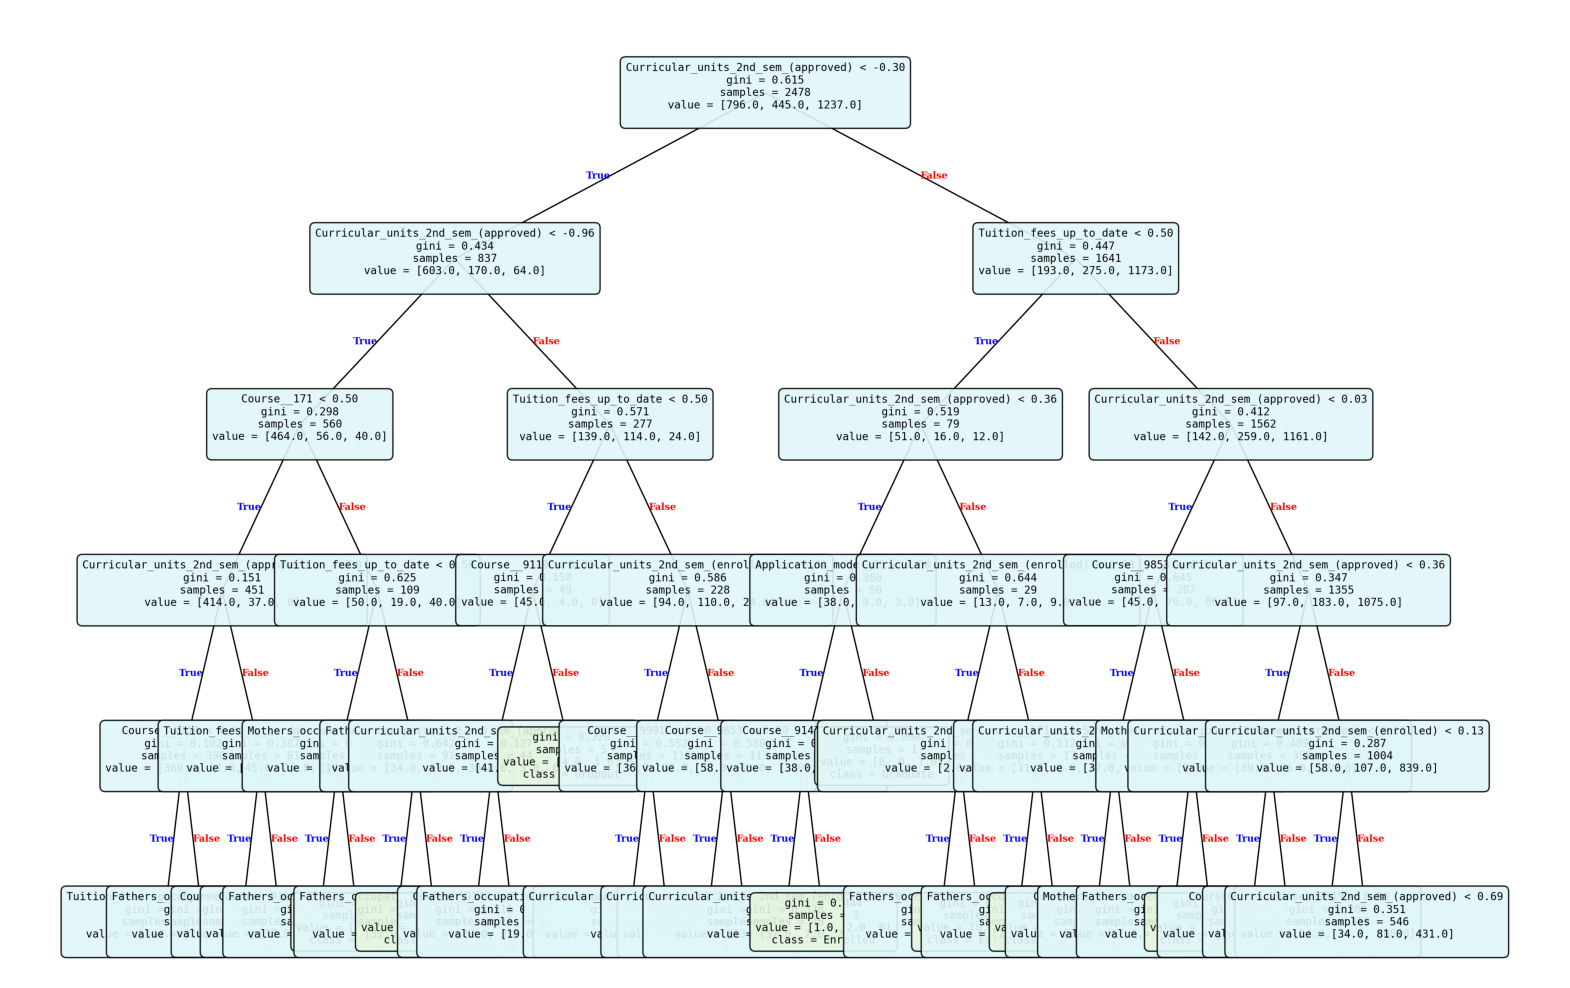

In [69]:
image = Image.open(f"../test/output/dtl.png")
plt.figure(figsize=(20, 20))
plt.imshow(image)
plt.axis('off')
plt.show()

# Logistic Regression Visualization

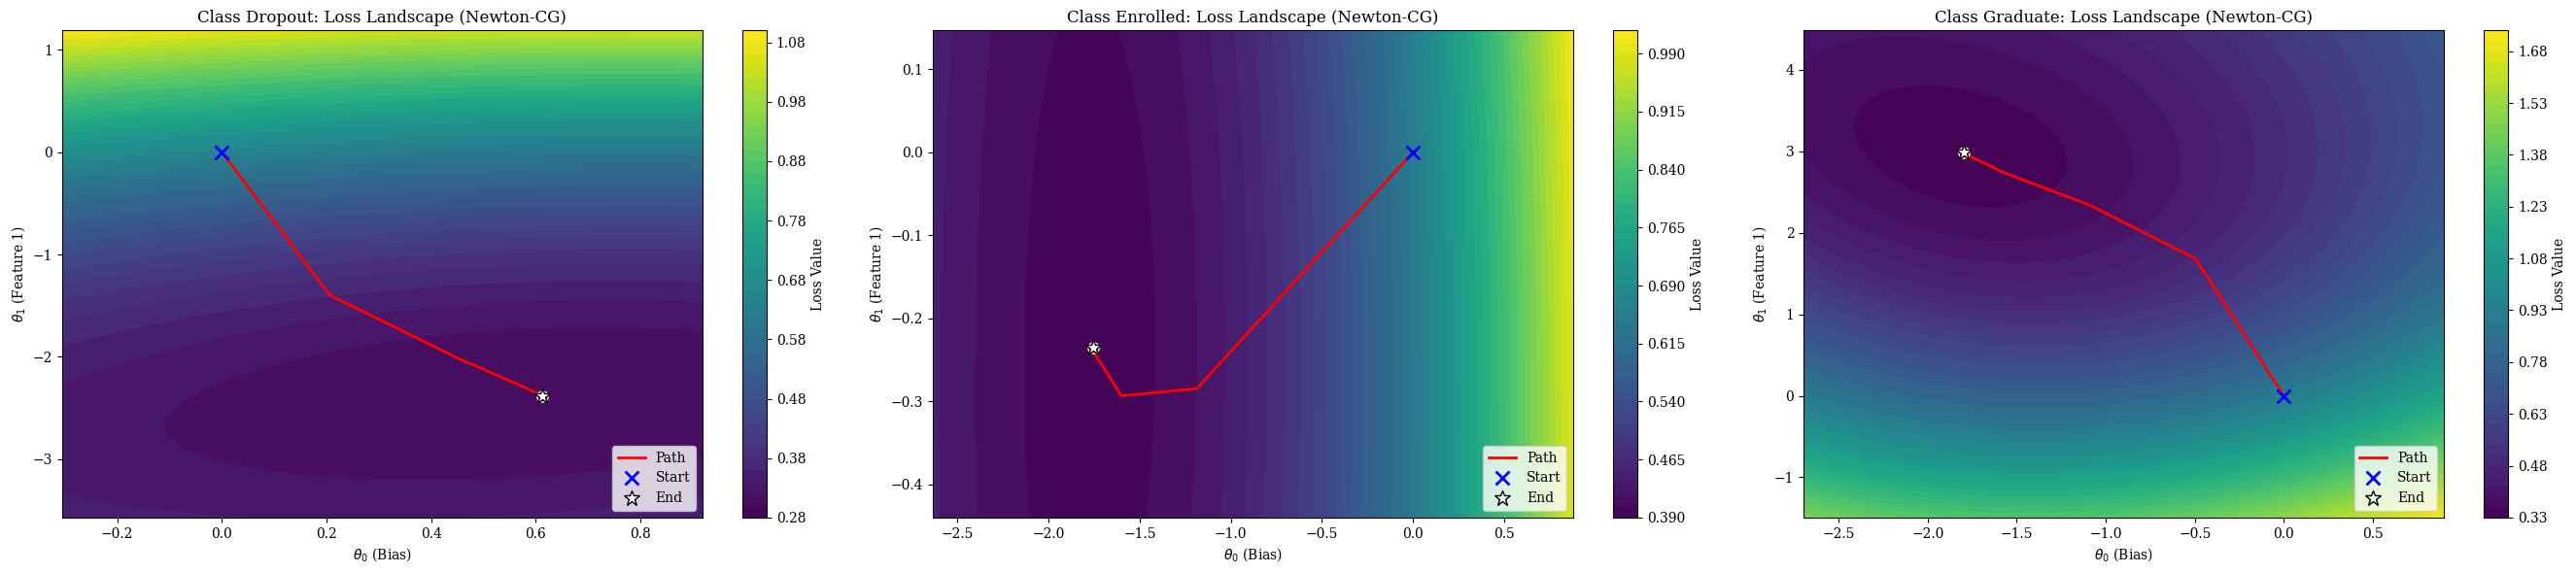

In [67]:
log.visualize_training(save_path="../test/output/logistic_training.mp4")